# Corrélations `statut` × caractéristiques — angle « cueilleur »

Notebook d'analyse **actionnable** : on cherche les règles qui aident un cueilleur à décider sur le terrain. Va plus loin que `visualisation_clean.ipynb` (qui se concentre sur les corrélations point-biserial) en calculant :

- **Lift** et **odds ratio** par feature (compatibles avec ce que le frontend Svelte calcule à la volée).
- **Croisement habitat × saison** pour identifier les fenêtres les moins risquées.
- **Importance des features** par information mutuelle.
- **Signatures à 2 features** : combinaisons les plus discriminantes.
- **Tests statistiques** (chi² / Fisher) sur les règles clés.
- **Synthèse de règles** : les chiffres directement repris dans la page Astuces (`web/frontend/src/routes/astuces`).

Source de données : `data/clean_web/champignons_clean.csv` (217 espèces, 158 features binaires + 4 tailles).

## 1. Chargement et préparation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, fisher_exact
from sklearn.feature_selection import mutual_info_classif

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 100

CLEAN_CSV = '../../data/clean_web/champignons_clean.csv'
df = pd.read_csv(CLEAN_CSV)
print(f'{len(df)} espèces, {len(df.columns)} colonnes')
df.head(2)

217 espèces, 165 colonnes


,nom,statut,a_un_chapeau,a_des_pores,a_des_lames,a_un_pied,a_de_la_chair,chapeau_couleur_blanc,chapeau_couleur_brun,chapeau_couleur_jaune,...,habitat_type_jardins,habitat_type_bois,habitat_type_chenes,habitat_type_hetres,habitat_type_pins,habitat_type_bouleaux,habitat_type_chataigniers,habitat_type_charmes,habitat_type_melezes,habitat_type_bois_morts
0,AGARIC AUGUSTE,Champignon à rejeter,1,0,1,1,1,1,1,1,...,0,1,0,0,0,0,0,0,0,0
1,AGARIC DES JACHÈRES,Les excellents champignons,1,0,1,1,1,1,0,1,...,0,0,0,0,0,0,0,0,0,0


In [2]:
# Mapping reproduit côté frontend (web/frontend/src/lib/data/insights.ts → dangerLevel)
DANGER_MAP = {
    'Les excellents champignons': 'safe',
    'Les bons champignons': 'safe',
    'Les champignons mediocres': 'safe',
    'Champignon à rejeter': 'risky',
    'Les champignons toxiques': 'risky',
    'Les champignons mortel': 'deadly',
}
df['danger'] = df['statut'].map(DANGER_MAP).fillna('safe')
df['danger'].value_counts()

C:\Users\benja\AppData\Local\Temp\ipykernel_7736\1375992871.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['danger'] = df['statut'].map(DANGER_MAP).fillna('safe')


danger
risky     107
safe      101
deadly      9
Name: count, dtype: int64

## 2. Rappel de la cible — distribution du danger

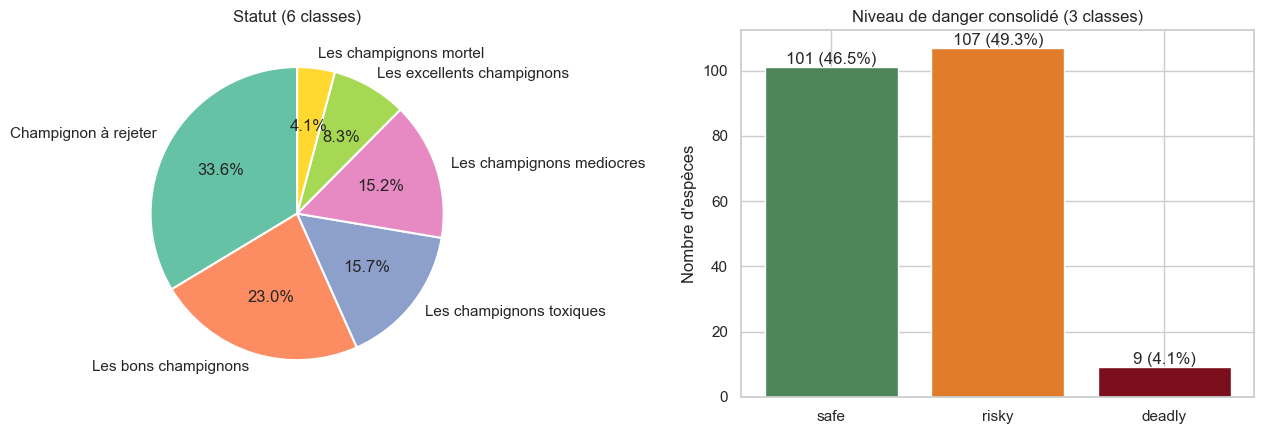

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

statut_counts = df['statut'].value_counts()
axes[0].pie(statut_counts.values, labels=statut_counts.index, autopct='%1.1f%%',
            startangle=90, colors=sns.color_palette('Set2', len(statut_counts)),
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[0].set_title('Statut (6 classes)')

danger_counts = df['danger'].value_counts().reindex(['safe', 'risky', 'deadly'])
colors = ['#4d8559', '#e07c2a', '#7a0e1a']
axes[1].bar(danger_counts.index, danger_counts.values, color=colors)
axes[1].set_title('Niveau de danger consolidé (3 classes)')
axes[1].set_ylabel("Nombre d'espèces")
for i, v in enumerate(danger_counts.values):
    axes[1].text(i, v + 1, f'{v} ({v/len(df)*100:.1f}%)', ha='center')

plt.tight_layout()
plt.show()

## 3. Helpers — bucketize, lift, odds ratio

Reproduisent exactement les fonctions Svelte de `web/frontend/src/lib/data/insights.ts` pour aligner les chiffres notebook ↔ frontend.

In [4]:
def bucket(sub: pd.DataFrame) -> dict:
    n = len(sub)
    if n == 0:
        return {'n': 0, 'safe': 0, 'risky': 0, 'deadly': 0,
                'pct_safe': 0.0, 'pct_risky': 0.0, 'pct_deadly': 0.0}
    counts = sub['danger'].value_counts()
    safe, risky, deadly = counts.get('safe', 0), counts.get('risky', 0), counts.get('deadly', 0)
    return {
        'n': n, 'safe': safe, 'risky': risky, 'deadly': deadly,
        'pct_safe': safe / n * 100,
        'pct_risky': risky / n * 100,
        'pct_deadly': deadly / n * 100,
    }

def lift(df: pd.DataFrame, mask: pd.Series, level: str) -> float:
    """P(level | feature) / P(level). >1 = la feature augmente le risque."""
    base_p = (df['danger'] == level).mean()
    if base_p == 0 or mask.sum() == 0:
        return 0.0
    p_with = (df.loc[mask, 'danger'] == level).mean()
    return p_with / base_p

def odds_ratio(df: pd.DataFrame, mask: pd.Series, level: str) -> float:
    """OR = (a/b) / (c/d) avec a=feature & danger, b=feature & ~danger, c=~feature & danger, d=~feature & ~danger."""
    is_lvl = df['danger'] == level
    a = ((mask) & is_lvl).sum()
    b = ((mask) & (~is_lvl)).sum()
    c = ((~mask) & is_lvl).sum()
    d = ((~mask) & (~is_lvl)).sum()
    if b == 0 or c == 0:
        return float('inf') if a > 0 else 0.0
    return (a * d) / (b * c)

def summary_for(df: pd.DataFrame, mask: pd.Series, label: str) -> dict:
    return {
        'feature': label,
        'n': int(mask.sum()),
        **{f'pct_{k}': round(v, 1) for k, v in bucket(df[mask]).items() if k.startswith('pct_')},
        'lift_risky': round(lift(df, mask, 'risky'), 2),
        'lift_deadly': round(lift(df, mask, 'deadly'), 2),
        'OR_risky': round(odds_ratio(df, mask, 'risky'), 2),
        'OR_deadly': round(odds_ratio(df, mask, 'deadly'), 2),
    }

## 4. Décisions de cueilleur — analyse par groupe

Chaque sous-section correspond à une **étape du guide pas à pas** dans la page Astuces.

### 4.1 Pied — volve, anneau, bulbe (drapeaux rouges)

In [5]:
pied_features = {
    'volve': df['pied_morpho_volve'] == 1,
    'anneau': df['pied_morpho_anneau'] == 1,
    'bulbe': df['pied_morpho_bulbe'] == 1,
    'volve OU anneau': (df['pied_morpho_volve'] == 1) | (df['pied_morpho_anneau'] == 1),
    'volve ET anneau': (df['pied_morpho_volve'] == 1) & (df['pied_morpho_anneau'] == 1),
}
rows_pied = [summary_for(df, m, label) for label, m in pied_features.items()]
df_pied = pd.DataFrame(rows_pied)
df_pied

,feature,n,pct_pct_safe,pct_pct_risky,pct_pct_deadly,lift_risky,lift_deadly,OR_risky,OR_deadly
0,volve,11,54.5,18.2,27.3,0.37,6.58,0.21,12.50
1,anneau,37,45.9,43.2,10.8,0.88,2.61,0.75,4.24
2,bulbe,12,50.0,50.0,0.0,1.01,0.00,1.03,0.00
3,volve OU anneau,39,48.7,41.0,10.3,0.83,2.47,0.67,3.95
4,volve ET anneau,9,44.4,22.2,33.3,0.45,8.04,0.28,16.83


### 4.2 Sous le chapeau — pores vs lames + couleurs

In [6]:
sous_chapeau = {
    'a des lames': df['a_des_lames'] == 1,
    'a des pores': df['a_des_pores'] == 1,
    'pores rouges/orange': (df['pores_couleur_rouge'] == 1) | (df['pores_couleur_orange'] == 1),
    'lames rouges': df['lames_couleur_rouge'] == 1,
    'lames blanches': df['lames_couleur_blanc'] == 1,
}
df_sc = pd.DataFrame([summary_for(df, m, l) for l, m in sous_chapeau.items()])
df_sc

,feature,n,pct_pct_safe,pct_pct_risky,pct_pct_deadly,lift_risky,lift_deadly,OR_risky,OR_deadly
0,a des lames,133,38.3,54.9,6.8,1.11,1.63,1.79,inf
1,a des pores,33,60.6,39.4,0.0,0.80,0.00,0.62,0.00
2,pores rouges/orange,4,25.0,75.0,0.0,1.52,0.00,3.14,0.00
3,lames rouges,7,28.6,42.9,28.6,0.87,6.89,0.76,11.60
4,lames blanches,49,46.9,51.0,2.0,1.03,0.49,1.09,0.42


### 4.3 Couleur du chapeau — démonter le mythe « rouge = poison »

In [7]:
chap_features = {
    f'chapeau {c}': df[f'chapeau_couleur_{c}'] == 1
    for c in ['blanc', 'brun', 'jaune', 'rouge', 'orange', 'gris', 'noir', 'vert', 'roux']
}
df_chap = pd.DataFrame([summary_for(df, m, l) for l, m in chap_features.items()])
df_chap.sort_values('pct_deadly', ascending=False)

KeyError: 'pct_deadly'

### 4.4 Odeur

In [ ]:
odeur_features = {
    'anisée': df['odeur_type_anise'] == 1,
    'amande': df['odeur_type_amande'] == 1,
    'fruitée': df['odeur_type_fruitee'] == 1,
    'farine': df['odeur_type_farine'] == 1,
    'phénol': df['odeur_type_phenol'] == 1,
    'iode': df['odeur_type_iode'] == 1,
    'désagréable/phénol/iode': (df['odeur_type_phenol'] == 1) | (df['odeur_type_iode'] == 1) | (df['odeur_type_desagreable'] == 1),
    'anisée/amande': (df['odeur_type_anise'] == 1) | (df['odeur_type_amande'] == 1),
}
pd.DataFrame([summary_for(df, m, l) for l, m in odeur_features.items()])

### 4.5 Saveur

In [ ]:
saveur_features = {
    'douce': df['saveur_type_douce'] == 1,
    'amère': df['saveur_type_amere'] == 1,
    'piquante': df['saveur_type_piquante'] == 1,
    'poivrée': df['saveur_type_poivree'] == 1,
    'amère/piquante/poivrée': (df['saveur_type_amere'] == 1) | (df['saveur_type_piquante'] == 1) | (df['saveur_type_poivree'] == 1),
}
pd.DataFrame([summary_for(df, m, l) for l, m in saveur_features.items()])

### 4.6 Tailles par niveau de danger

In [ ]:
df['chapeau_taille'] = (df['chapeau_taille_min_cm'] + df['chapeau_taille_max_cm']) / 2
df['pied_taille']    = (df['pied_taille_min_cm']    + df['pied_taille_max_cm'])    / 2

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
order = ['safe', 'risky', 'deadly']
palette = {'safe': '#4d8559', 'risky': '#e07c2a', 'deadly': '#7a0e1a'}

sns.boxplot(data=df, x='danger', y='chapeau_taille', order=order, palette=palette, ax=axes[0])
axes[0].set_title('Taille du chapeau (cm) par niveau de danger')
axes[0].set_xlabel('')

sns.boxplot(data=df, x='danger', y='pied_taille', order=order, palette=palette, ax=axes[1])
axes[1].set_title('Taille du pied (cm) par niveau de danger')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

df.groupby('danger')[['chapeau_taille', 'pied_taille']].agg(['mean', 'median', 'std']).round(2)

## 5. Croisement habitat × saison

Pour chaque (habitat, mois), on calcule le **% danger** (risky + deadly). Identifie les fenêtres les plus sûres pour sortir.

In [ ]:
habitats = ['feuillus', 'coniferes', 'foret', 'prairies', 'clairieres', 'lisieres',
            'jardins', 'bois', 'chenes', 'hetres', 'pins', 'bouleaux',
            'chataigniers', 'charmes', 'melezes', 'bois_morts']
mois_labels = ['Jan', 'Fév', 'Mar', 'Avr', 'Mai', 'Juin', 'Juil', 'Août', 'Sep', 'Oct', 'Nov', 'Déc']

rows = []
for h in habitats:
    h_col = f'habitat_type_{h}'
    if h_col not in df.columns:
        continue
    for i in range(1, 13):
        m_col = f'saison_mois_{i:02d}'
        if m_col not in df.columns:
            continue
        sub = df[(df[h_col] == 1) & (df[m_col] == 1)]
        if len(sub) == 0:
            rows.append({'habitat': h, 'mois': mois_labels[i-1], 'n': 0, 'pct_danger': np.nan})
        else:
            pct = (sub['danger'].isin(['risky', 'deadly'])).mean() * 100
            rows.append({'habitat': h, 'mois': mois_labels[i-1], 'n': len(sub), 'pct_danger': pct})

hs = pd.DataFrame(rows)
pivot_pct = hs.pivot(index='habitat', columns='mois', values='pct_danger').reindex(columns=mois_labels)
pivot_n   = hs.pivot(index='habitat', columns='mois', values='n').reindex(columns=mois_labels)

fig, ax = plt.subplots(figsize=(13, 7))
sns.heatmap(pivot_pct, cmap='RdYlGn_r', vmin=0, vmax=100, annot=pivot_n, fmt='g',
            cbar_kws={'label': '% espèces dangereuses (risky + deadly)'}, ax=ax,
            linewidths=0.3, linecolor='white')
ax.set_title('Habitat × saison — % danger (annotation : nombre d\'espèces)')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

In [ ]:
# Classement des habitats par % danger (toutes saisons)
habitat_rank = []
for h in habitats:
    h_col = f'habitat_type_{h}'
    if h_col not in df.columns:
        continue
    mask = df[h_col] == 1
    if mask.sum() < 5:
        continue
    habitat_rank.append({
        'habitat': h,
        'n': int(mask.sum()),
        'pct_safe': round((df.loc[mask, 'danger'] == 'safe').mean() * 100, 1),
        'pct_risky': round((df.loc[mask, 'danger'] == 'risky').mean() * 100, 1),
        'pct_deadly': round((df.loc[mask, 'danger'] == 'deadly').mean() * 100, 1),
        'pct_danger': round(df.loc[mask, 'danger'].isin(['risky', 'deadly']).mean() * 100, 1),
    })
df_habitat = pd.DataFrame(habitat_rank).sort_values('pct_danger')
df_habitat

## 6. Importance des features — information mutuelle

Quels critères apportent le plus d'information sur le danger ? Information mutuelle entre chaque feature binaire et la cible `danger` (3 classes).

In [ ]:
exclude = {'nom', 'statut', 'danger', 'chapeau', 'pores', 'lames', 'pied', 'chair',
           'odeur', 'saveur', 'habitat', 'saison',
           'chapeau_taille_min_cm', 'chapeau_taille_max_cm',
           'pied_taille_min_cm',    'pied_taille_max_cm',
           'chapeau_taille', 'pied_taille'}
binary_cols = [c for c in df.columns if c not in exclude
               and df[c].dtype != object
               and df[c].dropna().isin([0, 1]).all()]
print(f'{len(binary_cols)} features binaires analysées')

X = df[binary_cols].fillna(0).astype(int).values
y = df['danger'].astype('category').cat.codes.values
mi = mutual_info_classif(X, y, discrete_features=True, random_state=42)
mi_df = pd.DataFrame({'feature': binary_cols, 'mi': mi}).sort_values('mi', ascending=False)

top25 = mi_df.head(25)
fig, ax = plt.subplots(figsize=(10, 8))
sns.barplot(data=top25, y='feature', x='mi', palette='viridis', ax=ax)
ax.set_title('Top 25 features par information mutuelle avec danger')
ax.set_xlabel('Information mutuelle')
plt.tight_layout()
plt.show()

top25

## 7. Signatures à 2 features — paires les plus discriminantes

Pour chaque paire (f1, f2) avec au moins 5 espèces qui combinent les deux, on calcule le % mortels et risky. Les paires les plus dangereuses servent de **signatures** dans le guide.

In [ ]:
# Restreindre aux 30 features les plus informatives pour limiter la combinatoire
candidates = mi_df.head(30)['feature'].tolist()
pairs = []
for i, f1 in enumerate(candidates):
    for f2 in candidates[i+1:]:
        mask = (df[f1] == 1) & (df[f2] == 1)
        n = int(mask.sum())
        if n < 5:
            continue
        pairs.append({
            'f1': f1, 'f2': f2, 'n': n,
            'pct_deadly': round((df.loc[mask, 'danger'] == 'deadly').mean() * 100, 1),
            'pct_danger': round(df.loc[mask, 'danger'].isin(['risky', 'deadly']).mean() * 100, 1),
            'pct_safe': round((df.loc[mask, 'danger'] == 'safe').mean() * 100, 1),
        })
pairs_df = pd.DataFrame(pairs)
print(f'{len(pairs_df)} paires avec n ≥ 5')
print('\nTop 10 paires les plus DANGEREUSES (% risky + deadly) :')
pairs_df.sort_values('pct_danger', ascending=False).head(10)

In [ ]:
print('Top 10 paires les plus SÛRES (% safe) :')
pairs_df.sort_values('pct_safe', ascending=False).head(10)

## 8. Tests statistiques sur les règles clés du guide

In [ ]:
rules = {
    'volve OU anneau → mortel': ((df['pied_morpho_volve'] == 1) | (df['pied_morpho_anneau'] == 1), df['danger'] == 'deadly'),
    'pores rouges/orange → danger': ((df['pores_couleur_rouge'] == 1) | (df['pores_couleur_orange'] == 1), df['danger'].isin(['risky', 'deadly'])),
    'saveur amère/piquante → danger': ((df['saveur_type_amere'] == 1) | (df['saveur_type_piquante'] == 1) | (df['saveur_type_poivree'] == 1), df['danger'].isin(['risky', 'deadly'])),
    'odeur phénol/iode/désagréable → danger': ((df['odeur_type_phenol'] == 1) | (df['odeur_type_iode'] == 1) | (df['odeur_type_desagreable'] == 1), df['danger'].isin(['risky', 'deadly'])),
    'odeur anisée/amande → safe': ((df['odeur_type_anise'] == 1) | (df['odeur_type_amande'] == 1), df['danger'] == 'safe'),
    'a des pores → safe': (df['a_des_pores'] == 1, df['danger'] == 'safe'),
    'chapeau rouge → danger': (df['chapeau_couleur_rouge'] == 1, df['danger'].isin(['risky', 'deadly'])),
}

test_rows = []
for label, (feat, target) in rules.items():
    table = pd.crosstab(feat, target)
    if table.shape == (2, 2):
        a, b, c, d = table.iloc[0, 0], table.iloc[0, 1], table.iloc[1, 0], table.iloc[1, 1]
        # Fisher si une cellule < 5
        if min(a, b, c, d) < 5:
            _, p = fisher_exact([[a, b], [c, d]])
            test = 'Fisher'
        else:
            chi2, p, _, _ = chi2_contingency(table)
            test = 'Chi²'
    else:
        chi2, p, _, _ = chi2_contingency(table)
        test = 'Chi²'
    test_rows.append({
        'règle': label,
        'n_feature': int(feat.sum()),
        'pct_target_si_feature': round(target[feat].mean() * 100, 1) if feat.sum() else 0.0,
        'pct_target_global': round(target.mean() * 100, 1),
        'test': test,
        'p_value': f'{p:.4f}',
        'significatif (p<0.05)': p < 0.05,
    })
pd.DataFrame(test_rows)

## 9. Synthèse — règles actionnables pour le guide pas à pas

Ces chiffres sont ceux à reproduire dans la page Astuces (`web/frontend/src/lib/data/guide.ts`).

In [ ]:
synth = []
rules_synth = {
    'Volve OU anneau': (df['pied_morpho_volve'] == 1) | (df['pied_morpho_anneau'] == 1),
    'Volve seule': df['pied_morpho_volve'] == 1,
    'Pores rouges/orange': (df['pores_couleur_rouge'] == 1) | (df['pores_couleur_orange'] == 1),
    'Saveur amère/piquante/poivrée': (df['saveur_type_amere'] == 1) | (df['saveur_type_piquante'] == 1) | (df['saveur_type_poivree'] == 1),
    'Odeur phénol/iode/désagréable': (df['odeur_type_phenol'] == 1) | (df['odeur_type_iode'] == 1) | (df['odeur_type_desagreable'] == 1),
    'Odeur anisée/amande': (df['odeur_type_anise'] == 1) | (df['odeur_type_amande'] == 1),
    'A des pores (Bolets…)': df['a_des_pores'] == 1,
    'A des lames': df['a_des_lames'] == 1,
    'Habitat chênes': df['habitat_type_chenes'] == 1,
    'Habitat prairies': df['habitat_type_prairies'] == 1,
    'Saveur douce': df['saveur_type_douce'] == 1,
}
for label, mask in rules_synth.items():
    synth.append(summary_for(df, mask, label))

synth_df = pd.DataFrame(synth).sort_values('lift_deadly', ascending=False)
synth_df

In [ ]:
# Visualisation finale : lift mortel par règle
ordered = synth_df.copy()
ordered['lift_deadly_capped'] = ordered['lift_deadly'].clip(upper=10)  # cap pour lisibilité (∞)
fig, ax = plt.subplots(figsize=(10, 6))
colors_bar = ['#7a0e1a' if v >= 1.5 else ('#e07c2a' if v >= 1 else '#4d8559') for v in ordered['lift_deadly_capped']]
ax.barh(ordered['feature'], ordered['lift_deadly_capped'], color=colors_bar)
ax.axvline(1, color='grey', linestyle='--', linewidth=1, label='baseline (×1)')
ax.set_xlabel('Lift sur le risque mortel (×)')
ax.set_title('Règles synthétiques — lift mortel par critère')
ax.legend()
plt.tight_layout()
plt.show()

## Conclusion

Les chiffres clés à reporter dans la page Astuces (`web/frontend/src/lib/data/guide.ts`) :

1. **Pied** : volve et/ou anneau démultiplient le risque mortel — c'est le critère le plus discriminant.
2. **Sous le chapeau** : pores rouges/orange = signal fort de toxicité ; les bolets sains ont des pores blancs ou jaunes.
3. **Couleur du chapeau** : peu fiable seule (les Amanites mortelles sont souvent blanches ou verdâtres).
4. **Odeur** : phénol/iode = méfiance ; anisée/amande = tendance favorable mais pas une garantie.
5. **Saveur** : amère/piquante/poivrée = test simple et fiable — recracher.
6. **Habitat** : chênes, hêtres et bois mixtes hébergent plus d'Amanites mortelles que prairies.
7. **Combinaisons** (signatures à 2 features) : confirment qu'aucun critère isolé ne suffit, mais la combinaison (volve + chapeau verdâtre, pores rouges + chair bleuissante) bascule la décision.